In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from traffic_monitoring_ml.config import COLLISION_VALUE_MAP_PATH, CASUALTY_VALUE_MAP_PATH, VEHICLE_VALUE_MAP_PATH, X_TRAIN_PATH, Y_TRAIN_PATH, GROUPS_TRAIN_PATH, SELECTED_FEATURES_PATH
from traffic_monitoring_ml.utils import load_pickle, save_json, get_day_period_from_time
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GroupShuffleSplit

In [2]:
pd.set_option('display.max_columns', 100)

In [3]:
casualty_value_map = load_pickle(Path(CASUALTY_VALUE_MAP_PATH))
vehicle_value_map = load_pickle(Path(VEHICLE_VALUE_MAP_PATH))
collision_value_map = load_pickle(Path(COLLISION_VALUE_MAP_PATH))

In [4]:
X_train = (pd.read_parquet(Path(X_TRAIN_PATH))
           .replace(casualty_value_map)
           .replace(collision_value_map)
           .replace(vehicle_value_map))
y_train = pd.read_parquet(Path(Y_TRAIN_PATH)).squeeze()

In [5]:
X_train.head()

,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,casualty_injury_based,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,driver_imd_decile,escooter_flag,police_force,number_of_vehicles,number_of_casualties,date,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,second_road_class,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,trunk_road_flag,collision_injury_based,day_period
0,Pedestrian,Female,24,21 - 25,"In centre of carriageway - not on refuge, isla...",Unknown or other,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,More deprived 20-30%,Based on severity reporting,Car,No tow/articulation,unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),Not at or within 20 metres of junction,unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),Unknown,Not known or not requested,Not known,Data missing or out of range,Data missing or out of range,Data missing or out of range,Vehicle was not an e-scooter,Metropolitan Police,2,1,14/11/2020,Saturday,19:23,A,Single carriageway,30,Not at junction or within 20 metres,Not at junction or within 20 metres,unknown (self reported),Darkness - lighting unknown,Raining no high winds,Wet or damp,unknown (self reported),No hazards,Urban,Non-trunk,Based on severity reporting,evening
1,Pedestrian,Female,95,Over 75,"In carriageway, crossing elsewhere",Crossing from driver's nearside,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,Less deprived 40-50%,Based on severity reporting,Car,No tow/articulation,Turning right,East,North,On main carriageway (not in restricted lane),Entering main road,No skidding,No hit,Did not leave carriageway,No hit,Front,No,Not known or not requested,Male,28,26 - 35,Most deprived 10%,Vehicle was not an e-scooter,Nottinghamshire,1,1,12/07/2020,Sunday,14:37,Unclassified,Single carriageway,30,T or staggered junction,Unclassified,No physical crossing facility within 50m,Daylight,Fine no high winds,Dry,No,No hazards,Urban,Non-trunk,Based on severity reporting,afternoon
2,Pedestrian,Male,39,36 - 45,"In carriageway, crossing elsewhere",Crossing from driver's nearside,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,More deprived 10-20%,Based on Injury code reporting,Car,No tow/articulation,Going ahead,West,North,On main carriageway (not in restricted lane),Mid Junction - on roundabout or on main road,No skidding,No hit,Did not leave carriageway,No hit,Front,No,Not known or not requested,Not known,Data missing or out of range,Data missing or out of range,Data missing or out of range,Vehicle was not an e-scooter,Bedfordshire,1,1,26/11/2020,Thursday,21:00,Unclassified,Single carriageway,30,Crossroads,Unclassified,No physical crossing facility within 50m,Darkness - lights unlit,Fog or mist,Wet or damp,No,No hazards,Urban,Non-trunk,Based on Injury code reporting,night
3,Pedestrian,Male,63,56 - 65,On footway or verge,Unknown or other,Not car passenger,Not a bus or coach passenger,Not Known,Pedestrian,More deprived 20-30%,Based on Injury code reporting,Car,No tow/articulation,Going ahead,South West,North East,On main carriageway (not in restricted lane),Not at or within 20 metres of junction,No skidding,No hit,Did not leave carriageway,No hit,Did not impact,No,Not known or not requested,Male,64,56 - 65

### Features invalidas

In [6]:
X_train.columns

Index(['casualty_class', 'sex_of_casualty', 'age_of_casualty',
       'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement',
       'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'casualty_type',
       'casualty_imd_decile', 'casualty_injury_based', 'vehicle_type',
       'towing_and_articulation', 'vehicle_manoeuvre',
       'vehicle_direction_from', 'vehicle_direction_to',
       'vehicle_location_restricted_lane', 'junction_location',
       'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
       'first_point_of_impact', 'vehicle_left_hand_drive',
       'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver',
       'age_band_of_driver', 'driver_imd_decile', 'escooter_flag',
       'police_force', 'number_of_vehicles', 'number_of_casualties', 'date',
       'day_of_week', 'time', 'first_road_class', 'road_type', 'speed_limit',
       'junction_d

In [7]:
#No se pueden obtener en inferencia
X_train = X_train.drop(columns=[
    'pedestrian_road_maintenance_worker',
    'casualty_injury_based',
    'towing_and_articulation',
    'vehicle_direction_from',
    'vehicle_direction_to',
    'vehicle_location_restricted_lane',
    'journey_purpose_of_driver',
    'police_force',
    'collision_injury_based',
    'casualty_imd_decile',
    'driver_imd_decile',
])

In [8]:
X_train.columns

Index(['casualty_class', 'sex_of_casualty', 'age_of_casualty',
       'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement',
       'car_passenger', 'bus_or_coach_passenger', 'casualty_type',
       'vehicle_type', 'vehicle_manoeuvre', 'junction_location',
       'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
       'first_point_of_impact', 'vehicle_left_hand_drive', 'sex_of_driver',
       'age_of_driver', 'age_band_of_driver', 'escooter_flag',
       'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week',
       'time', 'first_road_class', 'road_type', 'speed_limit',
       'junction_detail', 'second_road_class', 'pedestrian_crossing',
       'light_conditions', 'weather_conditions', 'road_surface_conditions',
       'special_conditions_at_site', 'carriageway_hazards',
       'urban_or_rural_area', 'trunk_road_flag', 'day_period'],
      dtype='str')

In [9]:
#Nos quedamos con las agrupaciones de categorías de las edades
X_train = X_train.drop(columns=[
    'age_of_casualty',
    'age_of_driver',
])

In [10]:
X_train['day_period'] = X_train['time'].apply(lambda x: get_day_period_from_time(x))

In [11]:
#Variables que voy eligiendo eliminar a mano tras evaluar cada iteración de importancias
X_train = X_train.drop(columns=[
    'date',
    'time',
    'day_of_week',
    'casualty_class',
    'escooter_flag',
    'bus_or_coach_passenger',
    'car_passenger'
])

In [12]:
X_train.columns # Variables seleccionadas

Index(['sex_of_casualty', 'age_band_of_casualty', 'pedestrian_location',
       'pedestrian_movement', 'casualty_type', 'vehicle_type',
       'vehicle_manoeuvre', 'junction_location', 'skidding_and_overturning',
       'hit_object_in_carriageway', 'vehicle_leaving_carriageway',
       'hit_object_off_carriageway', 'first_point_of_impact',
       'vehicle_left_hand_drive', 'sex_of_driver', 'age_band_of_driver',
       'number_of_vehicles', 'number_of_casualties', 'first_road_class',
       'road_type', 'speed_limit', 'junction_detail', 'second_road_class',
       'pedestrian_crossing', 'light_conditions', 'weather_conditions',
       'road_surface_conditions', 'special_conditions_at_site',
       'carriageway_hazards', 'urban_or_rural_area', 'trunk_road_flag',
       'day_period'],
      dtype='str')

In [13]:
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups_train = pd.read_parquet(Path(GROUPS_TRAIN_PATH)).squeeze()

train_idx, val_idx = next(gss_val.split(X_train, y_train, groups_train))

X_tr = X_train.iloc[train_idx]
X_val = X_train.iloc[val_idx]
y_tr = y_train.iloc[train_idx]
y_val = y_train.iloc[val_idx]

cat_features = [col for col in X_train.columns if X_train[col].dtype in ['object', 'str']]

#para early stoping de catboost
eval_set = Pool(X_val, y_val, cat_features=cat_features)

ftr_model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.1,
    depth=8,
    verbose=True,
    eval_metric='AUC',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=20,
    auto_class_weights='Balanced',
)

ftr_model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_set)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7222586	best: 0.7222586 (0)	total: 272ms	remaining: 6m 47s
1:	total: 469ms	remaining: 5m 51s
2:	total: 678ms	remaining: 5m 38s
3:	total: 872ms	remaining: 5m 26s
4:	total: 1.05s	remaining: 5m 15s
5:	test: 0.7363581	best: 0.7363581 (5)	total: 1.27s	remaining: 5m 15s
6:	total: 1.5s	remaining: 5m 20s
7:	total: 1.7s	remaining: 5m 17s
8:	total: 1.89s	remaining: 5m 13s
9:	total: 2.04s	remaining: 5m 3s
10:	test: 0.7401644	best: 0.7401644 (10)	total: 2.23s	remaining: 5m 2s
11:	total: 2.46s	remaining: 5m 4s
12:	total: 2.65s	remaining: 5m 3s
13:	total: 2.86s	remaining: 5m 3s
14:	total: 3.02s	remaining: 4m 58s
15:	test: 0.7433039	best: 0.7433039 (15)	total: 3.19s	remaining: 4m 55s
16:	total: 3.39s	remaining: 4m 55s
17:	total: 3.55s	remaining: 4m 52s
18:	total: 3.75s	remaining: 4m 52s
19:	total: 3.9s	remaining: 4m 48s
20:	test: 0.7454719	best: 0.7454719 (20)	total: 4.05s	remaining: 4m 45s
21:	total: 4.2s	remaining: 4m 42s
22:	total: 4.4s	remaining: 4m 42s
23:	total: 4.59s	remaining: 4m 4

CatBoostClassifier(auto_class_weights='Balanced', depth=8, devices='0', early_stopping_rounds=20, eval_metric='AUC', iterations=1500, learning_rate=0.1, task_type='GPU', verbose=True)

In [14]:
model_importance = ftr_model.get_feature_importance()
permutation_importance = ftr_model.get_feature_importance(
    data=eval_set,
    type='LossFunctionChange'  #permutation importance en catboost
)

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'model_importance': model_importance,
    'permutation_importance': permutation_importance,

}).sort_values(by='permutation_importance',ascending=False)

In [15]:
feat_imp #resultado consistente

,feature,model_importance,permutation_importance
4,casualty_type,18.933228,0.016943
1,age_band_of_casualty,6.283654,0.002669
6,vehicle_manoeuvre,6.960563,0.002648
20,speed_limit,6.078501,0.002529
12,first_point_of_impact,6.922399,0.002375
10,vehicle_leaving_carriageway,3.421132,0.001396
16,number_of_vehicles,5.870658,0.001178
27,special_conditions_at_site,1.766202,0.000859
8,skidding_and_overturning,3.049895,0.000821
30,trunk_road_flag,2.031633,0.000682


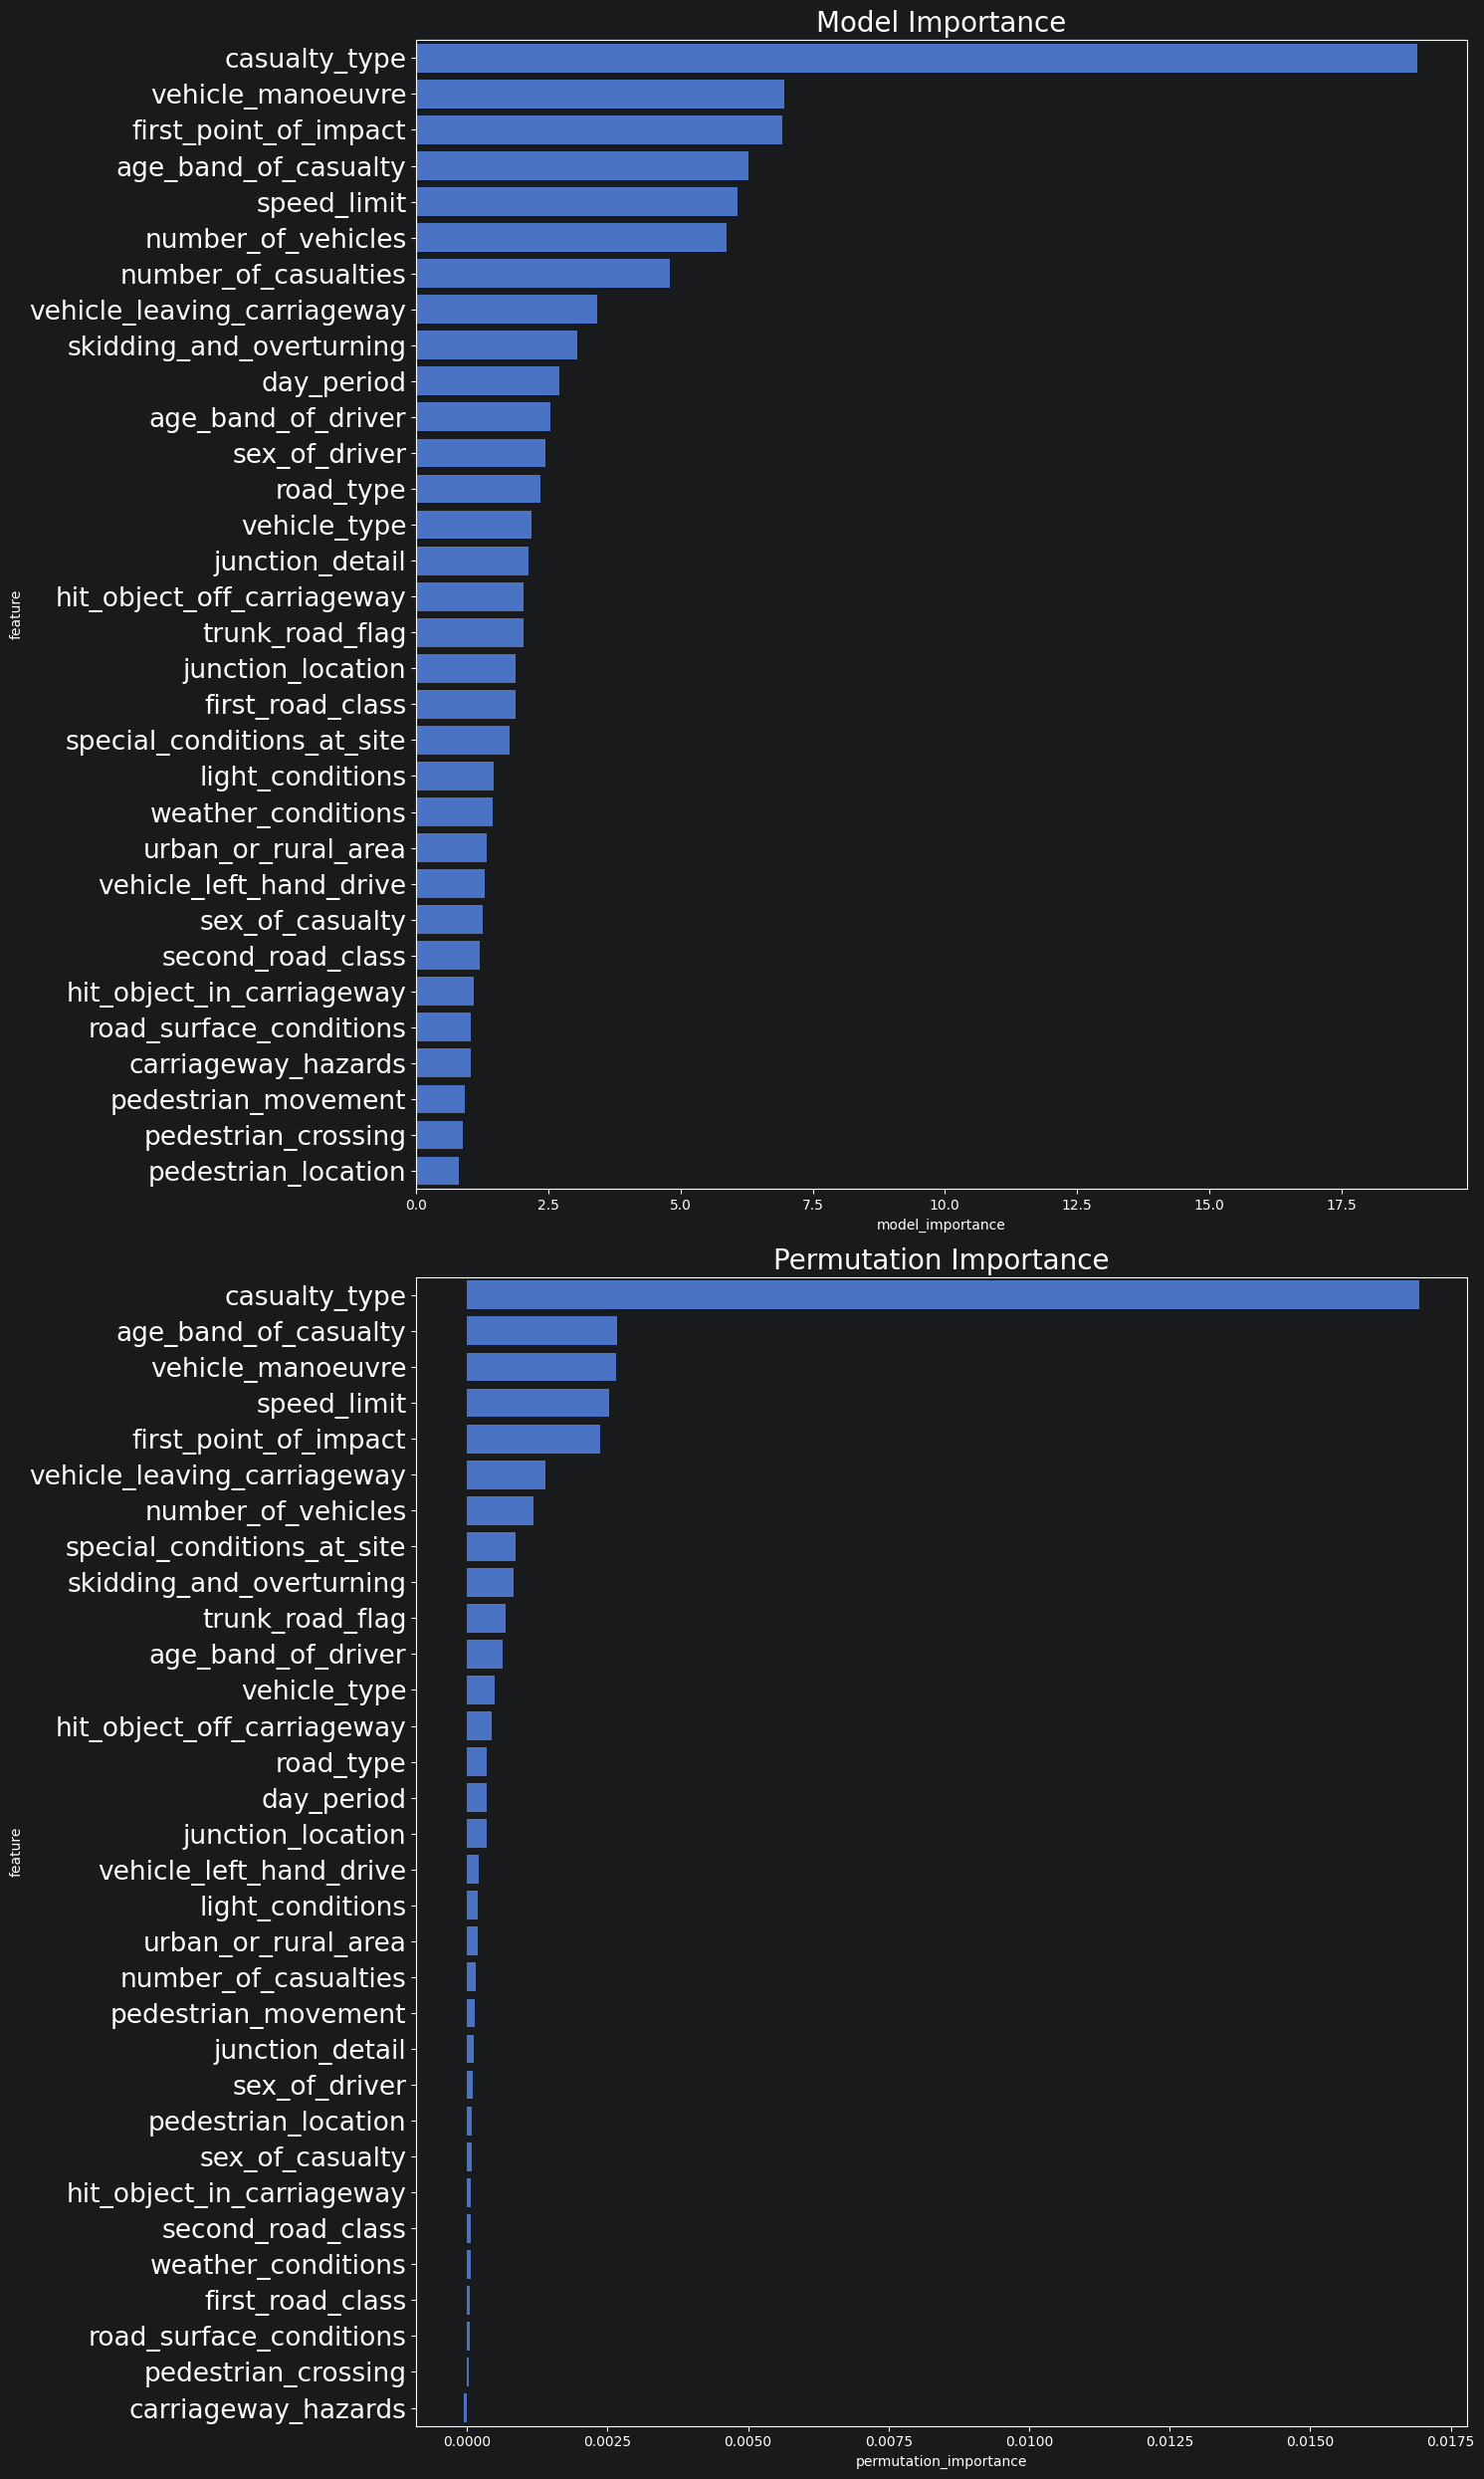

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(15, 25))

sns.barplot(data=feat_imp.sort_values(by='model_importance', ascending=False),x='model_importance',y='feature',ax=ax1)
ax1.tick_params(axis='y', labelsize=19)
ax1.set_title("Model Importance", size=20)

sns.barplot(data=feat_imp,x='permutation_importance',y='feature',ax=ax2
)
ax2.tick_params(axis='y', labelsize=19)
ax2.set_title('Permutation Importance', size=20)


plt.tight_layout()
plt.show()

In [17]:
save_json(Path(SELECTED_FEATURES_PATH), X_train.columns.tolist())